# Dataset 1 — Appliances Energy Prediction (UCI)  
**Situação**  
Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.  

---

Grupo:
| Nome | RM |
| --- | --- |
| Caio Marinho Pereira | 572873|
<br>


## Workflow Orange
Workflow realizado no Orange para mineração de dados. Não foram encontrados valores ausentes. Foi gerado uma amostra de 10% dos dados.  
untitled3.svg

## Import de Bibliotecas
Adiciona as bibliotecas de análise de dados que serão usadas.

In [312]:
import pandas as pd

## Carregar dados externos
Carrega a planilha com os dados, já tratados, e traduz o nome das colunas para o português.

In [313]:
dados1 = pd.read_csv('/content/appliances.csv')

In [314]:
dados1 = dados1.rename(columns = {'Appliances': 'Consumo_Eletrodomesticos',
                                'lights': 'Luzes',
                                'T1': 'Temperatura_1',
                                'RH_1' : 'Humidade_1',
                                'T2': 'Temperatura_2',
                                'RH_2' : 'Humidade_2',
                                'T3': 'Temperatura_3',
                                'RH_3' : 'Humidade_3'})

# Análise Exploratória
Processo inicial, responsável por investigar o conjunto de dados, resumir suas características principais e descobrir padrões.

Visualizar os primeiros registros

In [315]:
dados1.head()

,Consumo_Eletrodomesticos,Luzes,Temperatura_1,Humidade_1,Temperatura_2,Humidade_2,Temperatura_3,Humidade_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


Verificar a dimensão do dataframe

In [316]:
print(f"O número de registros do dataframe é: {dados1.shape[0]}")
print(f"O número de atributos do dataframe é: {dados1.shape[1]}")

O número de registros do dataframe é: 1974
O número de atributos do dataframe é: 8


Verificar informações sobre o formato dos dados

In [317]:
dados1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Consumo_Eletrodomesticos  1974 non-null   int64  
 1   Luzes                     1974 non-null   int64  
 2   Temperatura_1             1974 non-null   float64
 3   Humidade_1                1974 non-null   float64
 4   Temperatura_2             1974 non-null   float64
 5   Humidade_2                1974 non-null   float64
 6   Temperatura_3             1974 non-null   float64
 7   Humidade_3                1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


Verificar estatísticas descritivas das colunas numéricas

In [318]:
dados1.describe()

,Consumo_Eletrodomesticos,Luzes,Temperatura_1,Humidade_1,Temperatura_2,Humidade_2,Temperatura_3,Humidade_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


## Operações e Novos DataFrames
Realiza operações, como definição de limites, e cria um novo dataframe para cada uma.

### Maior consumo registrado

In [319]:
max_consumo = dados1['Consumo_Eletrodomesticos'].max()
print(f"O maior consumo registrado é de: {max_consumo:.3f} Wh")

O maior consumo registrado é de: 770.000 Wh


### Limiar de 70% desse máximo
Define um limite superior para o consumo correspondente a 70% do valor máximo registrado.

In [320]:
limiar_70 = max_consumo * .70
print(f"O limiar de 70% do consumo máximo equivale a: {limiar_70:.4f} Wh")

O limiar de 70% do consumo máximo equivale a: 539.0000 Wh


DataFrame com registros de consumo acima desse limiar

In [321]:
df_consumo_70 = dados1[dados1['Consumo_Eletrodomesticos'] > limiar_70]
df_consumo_70['Consumo_Eletrodomesticos'].head()

,Consumo_Eletrodomesticos
352,620
427,650
453,560
616,570
696,590


Quantidade e porcentagem de registros acima do limiar

In [322]:
print(f"A quantidade de registros acima do limiar é de: {df_consumo_70.shape[0]}")
porcent_70 = (df_consumo_70.shape[0] / dados1.shape[0]) * 100
print(f"Essa quantidade representa {porcent_70:.2f}% de registros do consumo total")

A quantidade de registros acima do limiar é de: 22
Essa quantidade representa 1.11% de registros do consumo total


### Média da Temperatura 1


In [323]:
media_t1 = dados1['Temperatura_1'].mean()
print(f"{media_t1:.4f}°C")

21.6647°C


Registros com Temperatura 1 alta e, simultaneamente, consumo alto

In [324]:
df_alta_t1_alto_consumo = dados1[(dados1['Temperatura_1'] > media_t1) & (dados1['Consumo_Eletrodomesticos'] > limiar_70)]
df_alta_t1_alto_consumo[['Temperatura_1', 'Consumo_Eletrodomesticos']].head()

,Temperatura_1,Consumo_Eletrodomesticos
352,24.3900,620
616,24.8900,570
916,22.4300,750
993,22.5333,690
1182,24.8900,600


### Efeito da inclusão da temperatura como segundo critério

A inclusão da temperatura como segundo critério reduz a quantidade de registros selecionados, pois agora o registro precisa atender simultaneamente às duas condições: apresentar consumo de eletrodomésticos acima de 70% do valor máximo e temperatura T1 acima da média. Assim, o segundo DataFrame representa um subconjunto mais específico dos períodos de consumo elevado. Além disso, a temperatura elevada pode ajudar a explicar o consumo elevado dos eletrodomésticos.

---

# Dataset 2 — Steel Industry Energy Consumption (UCI)  
**Situação**  
A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.  

## Workflow Orange
Workflow realizado no Orange para mineração de dados. Não foram encontrados valores ausentes. Foi gerado uma amostra de 20% dos dados.  
oangeworkflow.svg

### Load_Type e WeekStatus

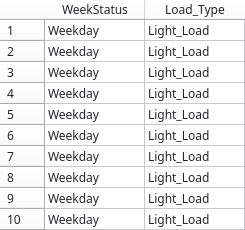

## Carregar dados externos
Carrega a planilha com os dados, já tratados, e traduz o nome das colunas para o português.

In [325]:
dados2 = pd.read_csv('/content/steel_data.csv')

In [326]:
dados2 = dados2.rename(columns = {'Usage_kWh': 'Consumo_kWh',
                                'Lagging_Current_Reactive.Power_kVarh': 'Corrente_Atrasada_kVarh',
                                'Leading_Current_Reactive_Power_kVarh': 'Corrente_Adiantada_kVarh',
                                'Lagging_Current_Power_Factor' : 'Fator_Potencia_Atrasada',
                                'Leading_Current_Power_Factor': 'Fator_Potencia_Adiantada',
                                'WeekStatus': 'Status_Semana',
                                'Day_of_week': 'Dia_Semana',
                                'Load_Type': 'Nivel_Carga'})

# Análise Exploratória
Processo inicial, responsável por investigar o conjunto de dados, resumir suas características principais e descobrir padrões.

Visualizar os primeiros registros

In [327]:
dados2.head()

,Consumo_kWh,Corrente_Atrasada_kVarh,Corrente_Adiantada_kVarh,Fator_Potencia_Atrasada,Fator_Potencia_Adiantada,Status_Semana,Dia_Semana,Nivel_Carga
0,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load


Verificar a dimensão do dataframe


In [328]:
print(f"O número de registros do dataframe é: {dados2.shape[0]}")
print(f"O número de atributos do dataframe é: {dados2.shape[1]}")

O número de registros do dataframe é: 7008
O número de atributos do dataframe é: 8


Verificar informações sobre o formato dos dados

In [329]:
dados2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Consumo_kWh               7008 non-null   float64
 1   Corrente_Atrasada_kVarh   7008 non-null   float64
 2   Corrente_Adiantada_kVarh  7008 non-null   float64
 3   Fator_Potencia_Atrasada   7008 non-null   float64
 4   Fator_Potencia_Adiantada  7008 non-null   float64
 5   Status_Semana             7008 non-null   object 
 6   Dia_Semana                7008 non-null   object 
 7   Nivel_Carga               7008 non-null   object 
dtypes: float64(5), object(3)
memory usage: 438.1+ KB


Verificar estatísticas descritivas das colunas numéricas

In [330]:
dados2.describe()

,Consumo_kWh,Corrente_Atrasada_kVarh,Corrente_Adiantada_kVarh,Fator_Potencia_Atrasada,Fator_Potencia_Adiantada
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


## Operações e Novos DataFrames
Realiza operações, como definição de limites, e cria um novo dataframe para cada uma.

### Maior consumo registrado

In [331]:
max_consumo = dados2['Consumo_kWh'].max()
print(f"O maior consumo registrado é de: {max_consumo:.3f} kWh")

O maior consumo registrado é de: 153.140 kWh


### Limiar de 75% desse máximo
Define um limite superior para o Consumo correspondente a 70% do valor máximo registrado.

In [332]:
limiar_75 = max_consumo * .75
print(f"O limiar de 75% do consumo máximo equivale a: {limiar_75:.3f} kWh")

O limiar de 75% do consumo máximo equivale a: 114.855 kWh


DataFrame com registros de consumo acima desse limiar

In [333]:
df_consumo_75 = dados2[dados2['Consumo_kWh'] > limiar_75]
df_consumo_75['Consumo_kWh'].head()

,Consumo_kWh
2,120.42
62,118.22
100,129.13
108,117.07
159,139.57


Quantidade e porcentagem de registros acima do limiar

In [334]:
print(f"A quantidade de registros acima do limiar é de: {df_consumo_75.shape[0]}")
porcent_75 = (df_consumo_75.shape[0] / dados2.shape[0]) * 100
print(f"Essa quantidade representa {porcent_75:.2f}% de registros do consumo total")

A quantidade de registros acima do limiar é de: 129
Essa quantidade representa 1.84% de registros do consumo total


Quantos registros acima do limiar pertencem à categoria Maximum Load

In [335]:
mask = (dados2['Nivel_Carga'] == 'Maximum_Load').reindex(df_consumo_75.index)
df_linear_maxload = df_consumo_75[mask]
df_linear_maxload[['Consumo_kWh', 'Nivel_Carga']].head()

,Consumo_kWh,Nivel_Carga
2,120.42,Maximum_Load
159,139.57,Maximum_Load
208,125.10,Maximum_Load
295,129.85,Maximum_Load
342,140.04,Maximum_Load


In [336]:
# contagem
print(f"A quantidade de registros acima do limiar que pertencem à categoria Maximum_Load é de: {df_linear_maxload.shape[0]} registros")
porcent_maxload = (df_linear_maxload.shape[0] / dados2.shape[0]) * 100
print(f"Essa quantidade representa {porcent_maxload:.2f}% de registros do consumo total")

A quantidade de registros acima do limiar que pertencem à categoria Maximum_Load é de: 62 registros
Essa quantidade representa 0.88% de registros do consumo total


### Fator de Potência Atrasada
Limite para representar valores mais baixos. Esse limite foi escolhido levando em consideração os 5% menores valores de Fator de Potência Atrasada.

In [337]:
limite_inf = dados2["Fator_Potencia_Atrasada"].quantile(0.05)
print(limite_inf)

46.8635


In [338]:
df_pot_lim = dados2[dados2['Fator_Potencia_Atrasada'] < limite_inf]
df_pot_lim['Fator_Potencia_Atrasada'].head()

,Fator_Potencia_Atrasada
12,46.82
22,43.51
52,41.48
87,45.99
138,40.62


Registros com potencia atrasada baixa e, simultaneamente, consumo alto

In [339]:
df_baixa_pot_alto_consumo = dados2[(dados2['Fator_Potencia_Atrasada'] < limite_inf) & (dados2['Consumo_kWh'] > limiar_75)]
df_baixa_pot_alto_consumo[['Fator_Potencia_Atrasada', 'Consumo_kWh']].head()

,Fator_Potencia_Atrasada,Consumo_kWh


In [340]:
print(f"Quantidade de registros: {df_baixa_pot_alto_consumo.shape[0]}")

Quantidade de registros: 0


### Porquê o conjunto Consumo Elevado e Fator de Potência Abaixo do Limite é importante:

Registros com consumo elevado e fator de potência baixo merecem maior atenção porque combinam uma condição de alta demanda de energia com um fator de potência menor, o que pode indicar uma utilização menos eficiente da energia elétrica e exigir uma análise de gestão de energia. Neste conjunto de dados, entretanto, nenhum registro apresentou, simultaneamente, consumo acima de 75% do máximo e fator de potência atrasada abaixo do limite. Portanto, não foram identificadas ocorrências que atendam simultaneamente aos dois critérios na amostra analisada.

---

# Dataset 3 — Power Consumption of Tetouan City (UCI)  
**Situação**  
Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda.


## Workflow Orange
Workflow realizado no Orange para mineração de dados. Não foram encontrados valores ausentes. Foi gerado uma amostra de 15% dos dados.  
untitled.svg

## Carregar dados externos
Carrega a planilha com os dados, já tratados, e traduz o nome das colunas para o português.

In [341]:
dados3 = pd.read_csv('/content/tetuan_power.csv')

In [342]:
dados3 = dados3.rename(columns = {'Temperature': 'Temperatura',
                                'Humidity': 'Humidade',
                                'Wind Speed': 'Velocidade_vento',
                                'Zone 1 Power Consumption': 'Consumo_Zona_1',
                                'Zone 2  Power Consumption': 'Consumo_Zona_2',
                                'Zone 3  Power Consumption': 'Consumo_Zona_3'})

### Maiores consumos registrados

Zona 1

In [343]:
max_consumo_1 = dados3['Consumo_Zona_1'].max()
print(f"O maior consumo registrado é de: {max_consumo_1:.3f} kWh")

O maior consumo registrado é de: 51571.500 kWh


Zona 2

In [344]:
max_consumo_2 = dados3['Consumo_Zona_2'].max()
print(f"O maior consumo registrado é de: {max_consumo_2:.3f} kWh")

O maior consumo registrado é de: 36437.200 kWh


Zona 3

In [345]:
max_consumo_3 = dados3['Consumo_Zona_3'].max()
print(f"O maior consumo registrado é de: {max_consumo_3:.3f} kWh")

O maior consumo registrado é de: 47441.700 kWh


### Zona com maior pico

In [346]:
colunas_zonas = ['Consumo_Zona_1', 'Consumo_Zona_2', 'Consumo_Zona_3']

zona_maior_pico = dados3[colunas_zonas].max().idxmax()
print(f"Zona com o maior pico: {zona_maior_pico}")


Zona com o maior pico: Consumo_Zona_1


### 70% do valor máximo
Define um limite superior para o Consumo da Zona 1 correspondente a 70% do valor máximo registrado.

In [347]:
limite_70 = max_consumo_1 * .70
print(f"O limite de 70% do consumo máximo da zona 1 equivale a: {limite_70:.3f} kWh")

O limite de 70% do consumo máximo da zona 1 equivale a: 36100.050 kWh


DataFrame com registros de consumo acima desse limite

In [348]:
df_consumo_70 = dados3[dados3['Consumo_Zona_1'] > limite_70]
df_consumo_70['Consumo_Zona_1'].head()

,Consumo_Zona_1
3,42476.9
8,37286.7
12,40993.9
14,37475.2
19,40676.0


Quantidade e porcentagem de registros acima do limiar

In [349]:
print(f"A quantidade de registros acima do limite é de: {df_consumo_70.shape[0]}")
porcent_70 = (df_consumo_70.shape[0] / dados3.shape[0]) * 100
print(f"Essa quantidade representa {porcent_70:.2f}% de registros do consumo total da zona 1")

A quantidade de registros acima do limite é de: 2388
Essa quantidade representa 30.37% de registros do consumo total da zona 1


### Temperatura Média


In [350]:
temp_media = dados3['Temperatura'].mean()
print(f"{temp_media:.2f}°C")

18.79°C


Registros com temperatura acima da media e, simultaneamente, consumo alto da zona 1



In [351]:
df_temp_consumo = dados3[(dados3['Temperatura'] > temp_media) & (dados3['Consumo_Zona_1'] > limite_70)]
df_temp_consumo[['Temperatura', 'Consumo_Zona_1']].head()

,Temperatura,Consumo_Zona_1
12,21.03,40993.9
14,27.06,37475.2
19,19.20,40676.0
21,27.11,40256.1
25,26.92,36511.9


### O que aconteceu com a quantidade de registros após a inclusão da condição ambiental

Com a inclusão da condição ambiental de Temperatura, ocorreu a:

* Redução na quantidade de dados (Filtragem Estrita): Ao adicionar a condição ambiental (Temperatura > temp_media), o filtro passa a utilizar o operador lógico E (&). Isso exige que ambas as condições sejam verdadeiras ao mesmo tempo para que uma linha seja mantida. Como resultado, a quantidade de registros no segundo DataFrame será menor ou igual à do primeiro.

* Eliminação de falsos positivos ambientais: O primeiro conjunto captura todos os picos de consumo, independentemente do motivo (como horários de pico comercial ou dias úteis). O segundo conjunto descarta os momentos de alto consumo que ocorreram em temperaturas amenas ou frias, isolando os registros de alto consumo que também ocorreram em temperaturas acima da média

---

# Dataset 4 — Solar Power Generation Data (Kaggle)
**Situação**  
Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. Nesta atividade, o foco inicial será o arquivo de geração da planta, sem realizar junção com o arquivo de sensores.


## Workflow Orange
Workflow realizado no Orange para mineração de dados. Não foram encontrados valores ausentes. Foi gerado uma amostra de 20% dos dados.  
plat1.svg


## Carregar dados externos
Carrega a planilha com os dados, já tratados, e traduz o nome das colunas para o português.

In [352]:
dados4 = pd.read_csv('/content/plant1.csv')

In [353]:
dados4 = dados4.rename(columns = {'DC_POWER': 'Potencia_CC',
                                'AC_POWER': 'Potencia_CA',
                                'DAILY_YIELD': 'Geracao_diaria',
                                'TOTAL_YIELD': 'Geracao_total',
                                'DATE_TIME': 'Data_hora'})

### Análise Exploratória


In [354]:
dados4.head()

,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_diaria,Geracao_total,Data_hora
0,uHbuxQJl8lW7ozc,0.00,0.000,6645.000,7240510.0,2020-06-10 19:00:00
1,rGa61gmuvPhdLxV,0.00,0.000,0.000,7206550.0,2020-05-28 00:15:00
2,sjndEbLyjtCKgGv,7333.88,718.062,6442.000,7036060.0,2020-05-17 15:15:00
3,ih0vzX44oOqAx2f,0.00,0.000,0.000,6308230.0,2020-06-01 04:15:00
4,z9Y9gH1T5YWrNuG,7665.50,750.438,961.375,7021700.0,2020-05-17 09:00:00


In [355]:
dados4.shape

(13756, 6)

In [356]:
dados4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13756 entries, 0 to 13755
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SOURCE_KEY      13756 non-null  object 
 1   Potencia_CC     13756 non-null  float64
 2   Potencia_CA     13756 non-null  float64
 3   Geracao_diaria  13756 non-null  float64
 4   Geracao_total   13756 non-null  float64
 5   Data_hora       13756 non-null  object 
dtypes: float64(4), object(2)
memory usage: 644.9+ KB


In [357]:
dados4.describe()

,Potencia_CC,Potencia_CA,Geracao_diaria,Geracao_total
count,13756.000000,13756.000000,13756.000000,1.375600e+04
mean,3135.848662,306.695495,3319.235216,6.978829e+06
std,4023.069619,393.124284,3142.249927,4.162164e+05
min,0.000000,0.000000,0.000000,6.183640e+06
25%,0.000000,0.000000,0.000000,6.509780e+06
50%,370.071500,35.771400,2730.425000,7.146220e+06
75%,6350.562500,622.065500,6293.782500,7.268000e+06
max,14416.100000,1405.590000,9163.000000,7.846820e+06


### Maior valor de Potencia_CA

In [358]:
maior_ca = dados4['Potencia_CA'].max()

print(f"Maior valor de Potência CA registrada: {maior_ca:.3f} kW")


Maior valor de Potência CA registrada: 1405.590 kW


### 70% do valor máximo
Define um limite superior para a Potência CA correspondente a 70% do valor máximo registrado.

In [359]:
limite_70 = maior_ca * .70
print(f"O limite de 70% da potência CA máxima equivale a: {limite_70:.3f} kW")

O limite de 70% da potência CA máxima equivale a: 983.913 kW


DataFrame com registros de consumo acima desse limite

In [360]:
df_consumo_70 = dados4[dados4['Potencia_CA'] > limite_70]
df_consumo_70['Potencia_CA'].head()

,Potencia_CA
11,1153.83
46,1032.07
48,1079.86
72,1082.44
76,1234.69


Quantidade e porcentagem de registros acima do limiar

In [361]:
print(f"A quantidade de registros acima do limite é de: {df_consumo_70.shape[0]}")
porcent_70 = (df_consumo_70.shape[0] / dados4.shape[0]) * 100
print(f"Essa quantidade representa {porcent_70:.2f}% de registros da Potencia CA")

A quantidade de registros acima do limite é de: 1185
Essa quantidade representa 8.61% de registros da Potencia CA


### SOURCE_KEY nesse DataFrame


In [362]:
contagem = df_consumo_70['SOURCE_KEY'].value_counts()
contagem

,count
SOURCE_KEY,
adLQvlD726eNBSB,68
McdE0feGgRqW7Ca,65
ZnxXDlPa8U1GXgE,63
pkci93gMrogZuBj,62
ZoEaEvLYb1n2sOq,61
1IF53ai7Xc0U56Y,59
YxYtjZvoooNbGkE,58
sjndEbLyjtCKgGv,57
z9Y9gH1T5YWrNuG,56


### Inversor que aparece com maior frequência nos registros

O inversor adLQvlD726eNBSB foi o que apareceu com maior frequência nos registros de alta geração, com 68 ocorrências. Isso indica que ele possui a maior quantidade de registros dentro do recorte analisado. Entretanto, essa frequência, isoladamente, não permite concluir que o inversor apresenta melhor desempenho, maior disponibilidade ou menor ocorrência de falhas. Seria necessário analisar outros dados e um período mais amplo para realizar esse tipo de avaliação.

---

# Dataset 5 — Wind & Solar Energy Production (Kaggle)
**Situação**  
Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.


## Workflow Orange
Workflow realizado no Orange para mineração de dados. Não foram encontrados valores ausentes. Foi gerado uma amostra de 20% dos dados.  
untitled2.svg

## Carregar dados externos
Carrega a planilha com os dados, já tratados, e traduz o nome das colunas para o português.

In [363]:
dados5 = pd.read_csv('/content/wind_solar.csv')

solar = dados5[dados5["Source"] == "Solar"].copy()
eolica = dados5[dados5["Source"] == "Wind"].copy()

In [364]:
solar = solar.rename(columns = {'Date': 'Data',
                                'Start_Hour': 'Horario_inicial',
                                'End_Hour': 'Horario_final',
                                'Source': 'Fonte',
                                'Day-of_Year': 'Dia_do_ano',
                                'Day_Name': 'Dia_nome',
                                'Month_Name': 'Mes_nome',
                                'Season': 'Estacao',
                                'Production': 'Geracao_solar'})

eolica = eolica.rename(columns = {'Date': 'Data',
                                'Start_Hour': 'Horario_inicial',
                                'End_Hour': 'Horario_final',
                                'Source': 'Fonte',
                                'Day-of_Year': 'Dia_do_ano',
                                'Day_Name': 'Dia_nome',
                                'Month_Name': 'Mes_nome',
                                'Season': 'Estacao',
                                'Production': 'Geracao_eolica'})

## Maiores valores de Produção



### Solar

In [365]:
maior_sol = solar['Geracao_solar'].max()
print(f"Maior valor de Produção Solar registrada: {maior_sol:.3f} MWh")


Maior valor de Produção Solar registrada: 16316.000 MWh


### Eólica

In [366]:
maior_wind = eolica['Geracao_eolica'].max()
print(f"Maior valor de Produção Eólica registrada: {maior_wind:.3f} MWh")


Maior valor de Produção Eólica registrada: 22929.000 MWh


### 70% do valor máximo Solar


In [367]:
solar_70 = maior_sol * .70
print(f"70% do máximo de produção solar equivale a: {solar_70:.3f} MWh")

70% do máximo de produção solar equivale a: 11421.200 MWh


Dataframe com registros acima desse valor

In [368]:
df_solar_70 = solar[solar['Geracao_solar'] > solar_70]
df_solar_70.head()

,Fonte,Horario_final,Horario_inicial,Data,Geracao_solar
77,Solar,14,13,7/8/2025,13125
178,Solar,14,13,3/19/2025,13786
183,Solar,13,12,8/17/2025,11455
187,Solar,13,12,7/16/2025,16160
207,Solar,13,12,3/31/2025,12441


Quantidade e porcentagem de registros acima de 70%

In [369]:
print(f"A quantidade de registros acima desse valor: {df_solar_70.shape[0]}")
solar_porcent_70 = (df_solar_70.shape[0] / solar.shape[0]) * 100
print(f"Essa quantidade representa {solar_porcent_70:.2f}% de registros da Produção Solar")

A quantidade de registros acima desse valor: 45
Essa quantidade representa 2.44% de registros da Produção Solar


### 70% do valor máximo Eólica

In [370]:
eolica_70 = maior_wind * .70
print(f"70% do máximo de produção eólica equivale a: {eolica_70:.3f} MWh")

70% do máximo de produção eólica equivale a: 16050.300 MWh


Dataframe com registros acima desse valor

In [371]:
df_eolica_70 = eolica[eolica['Geracao_eolica'] > eolica_70]
df_eolica_70.head()

,Fonte,Horario_final,Horario_inicial,Data,Geracao_eolica
20,Wind,1,0,1/3/2024,17272
32,Wind,14,13,3/11/2021,16144
103,Wind,1,0,1/29/2025,18199
151,Wind,7,6,12/8/2024,16946
192,Wind,3,2,11/19/2024,16568


Quantidade e porcentagem de registros acima de 70%

In [372]:
print(f"A quantidade de registros acima desse valor: {df_eolica_70.shape[0]}")
eolica_porcent_70 = (df_eolica_70.shape[0] / eolica.shape[0]) * 100
print(f"Essa quantidade representa {eolica_porcent_70:.2f}% de registros da Produção Eólica")

A quantidade de registros acima desse valor: 245
Essa quantidade representa 2.87% de registros da Produção Eólica


### Comparar qual fonte aparece mais acima de 70%

In [373]:
if eolica_porcent_70 > solar_porcent_70:
  print("A Energia Eólica apresenta maior percentual de registros de produção acima de 70% do seu máximo.")
elif eolica_porcent_70 < solar_porcent_70:
  print("A Energia Solara apresenta maior percentual de registros de produção acima de 70% do seu máximo.")
else:
  print("As duas fontes energéticas apresentam a mesma quantidade de registros de produção acima de 70% do seu máximo")

A Energia Eólica apresenta maior percentual de registros de produção acima de 70% do seu máximo.


### Por que não seria adequado utilizar o mesmo valor numérico de potência como limite para as duas fontes?

Não seria adequado utilizar diretamente o mesmo valor numérico de potência como limite para as duas fontes porque a produção de energia eólica e solar pode apresentar valores máximos diferentes. Por exemplo, se a produção máxima solar for muito maior que a eólica, usar um único limite faria com que esse valor representasse uma porcentagem diferente do máximo de cada fonte.

Por isso, é mais adequado calcular o limite de 70% individualmente para cada fonte, usando o próprio valor máximo de produção. Assim, a comparação é feita de forma justa, considerando a escala de cada variável.

---

# Dataset 6 — Individual Household Electric Power Consumption (UCI)
**Situação**  
Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio. O dataset é o mesmo utilizado como referência em aula, mas o critério de análise será diferente.

## Workflow Orange
Workflow realizado no Orange para mineração de dados. Os valores ausentes foram tratados. Foi gerado uma amostra de 10% dos dados.  
plat1.svg


## Carregar dados externos
Carrega a planilha com os dados, já tratados, e traduz o nome das colunas para o português.

In [374]:
dados6 = pd.read_csv('/content/household.csv')

In [375]:
dados6.shape

(204928, 7)

In [376]:
dados6 = dados6.rename(columns = {'Global_active_power': 'Potencia_global_ativa',
                                'Global_reactive_power': 'Potencia_global_reativa',
                                'Voltage': 'Tensao',
                                'Global_intensity': 'Corrente_global',
                                'Sub_metering_1': 'Sub_medicao_1',
                                'Sub_metering_2': 'Sub_medicao_2',
                                'Sub_metering_3': 'Sub_medicao_3'})

### Valor máximo da potência ativa

In [377]:
pot_max = dados6['Potencia_global_ativa'].max()
print(f"A maior potência ativa registrada é de: {pot_max:.3f} kW")

A maior potência ativa registrada é de: 10.536 kW


### 75% do valor máximo

In [378]:
limite_75 = pot_max * .75
print(f"O limite de 75% da potencia ativa equivale a: {limite_75:.3f} kW")

O limite de 75% da potencia ativa equivale a: 7.902 kW


DataFrame com registros de consumo acima desse limite

In [379]:
df_pot_75 = dados6[dados6['Potencia_global_ativa'] > limite_75]
df_pot_75['Potencia_global_ativa'].head()

,Potencia_global_ativa
3132,8.540
3630,8.278
10339,8.026
11695,8.102
27983,10.290


Quantidade e porcentagem de registros acima do limiar

In [380]:
print(f"A quantidade de registros acima do limite é de: {df_pot_75.shape[0]}")
porcent_75 = (df_pot_75.shape[0] / dados6.shape[0]) * 100
print(f"Essa quantidade representa {porcent_75:.2f}% de registros da Potencia Ativa")

A quantidade de registros acima do limite é de: 58
Essa quantidade representa 0.03% de registros da Potencia Ativa


### Corrente média da amostra


In [381]:
corrente_media = dados6['Corrente_global'].mean()
print(f"Média da corrente: {corrente_media:.4f} A")

Média da corrente: 4.6344 A


### Dataframe que apresenta, simultaneamente, Potência Ativa acima de 75% do máximo e Corrente acima da média

In [382]:
df_pot_alta_corrente_alta = dados6[(dados6['Potencia_global_ativa'] > limite_75) & (dados6['Corrente_global'] > corrente_media)]
df_pot_alta_corrente_alta.head()

,Potencia_global_ativa,Potencia_global_reativa,Tensao,Corrente_global,Sub_medicao_1,Sub_medicao_2,Sub_medicao_3
3132,8.540,0.238,236.23,36.0,80,35,17
3630,8.278,0.088,231.50,35.6,0,71,17
10339,8.026,0.066,236.45,33.8,37,73,18
11695,8.102,0.190,229.31,35.4,35,35,17
27983,10.290,0.302,230.90,44.6,35,66,17


### Efeito da inclusão da corrente

Ao considerar potência acima de 75% do máximo e corrente acima da média simultaneamente, a análise fica mais específica. A potência ativa elevada indica maior demanda elétrica, enquanto a corrente elevada mostra maior circulação de corrente no sistema. Como potência e corrente estão relacionadas pela tensão, observar as duas variáveis permite identificar períodos de produção elevada acompanhados de maior intensidade elétrica.

Assim, a inclusão da corrente funciona como um filtro adicional. Registros que possuem potência alta, mas corrente abaixo da média, são excluídos. O segundo conjunto, portanto, representa situações mais específicas de alta produção associada a alta corrente, tornando a análise mais rigorosa.
